In [1]:
# [CELL 1]: RESEARCH DEPENDENCIES
!pip install -q kaggle h5py matplotlib seaborn scikit-learn

In [2]:
import os
import h5py
import pickle
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files, drive
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models, callbacks

# Mount Drive for persistent CV-ANN weight storage
drive.mount('/content/drive')
RES_DIR = "/content/drive/MyDrive/Mod_Class_Research"
CP_DIR = os.path.join(RES_DIR, "checkpoints")
os.makedirs(CP_DIR, exist_ok=True)

# Define master knowledge path
MODEL_WEIGHTS_PATH = os.path.join(CP_DIR, "cv_ann_modulation_chunk_9.keras")
print(f"Namespace established. Master weights location: {MODEL_WEIGHTS_PATH}")

Mounted at /content/drive
Namespace established. Master weights location: /content/drive/MyDrive/Mod_Class_Research/checkpoints/cv_ann_modulation_chunk_9.keras


In [3]:
# [CELL 3]: KAGGLE API & HDF5 CHUNK EXTRACTION

if not os.path.exists("/root/.kaggle/kaggle.json"):
    uploaded = files.upload()
    os.makedirs("/root/.kaggle", exist_ok=True)
    for fn in uploaded.keys(): os.rename(fn, "/root/.kaggle/kaggle.json")
    os.chmod("/root/.kaggle/kaggle.json", 600)


!kaggle datasets download -d elpantherd/fmgmskoqpsk
!unzip -q fmgmskoqpsk.zip -d ./chunk_data
!rm fmgmskoqpsk.zip

import os
h5_path = './chunk_data/chunk_9.h5'
if os.path.exists(h5_path):
    print(f"HDF5 Volume Verified: {h5_path}")
else:
    # Diagnostic to check if the file name inside the zip is different
    print("Listing extracted files:", os.listdir('./chunk_data'))

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/elpantherd/fmgmskoqpsk
License(s): unknown
 99% 2.23G/2.25G [00:18<00:00, 113MB/s] 
100% 2.25G/2.25G [00:18<00:00, 129MB/s]
HDF5 Volume Verified: ./chunk_data/chunk_9.h5


In [4]:
import h5py
with h5py.File(h5_path, 'r') as f:
    print("Internal HDF5 Keys Found:", list(f.keys()))


Internal HDF5 Keys Found: ['X_test', 'X_train', 'Y_test', 'Y_train', 'Z_test', 'Z_train']


In [5]:
import h5py
import pandas as pd
import numpy as np
from IPython.display import display

def inspect_dataset(file_path):
    classes = ['OOK','4ASK','8ASK','BPSK','QPSK','8PSK','16PSK','32PSK',
               '16APSK','32APSK','64APSK','128APSK','16QAM','32QAM',
               '64QAM','128QAM','256QAM','AM-SSB-WC','AM-SSB-SC',
               'AM-DSB-WC','AM-DSB-SC','FM','GMSK','OQPSK']

    with h5py.File(file_path, 'r') as f:
        print(f"File: {file_path}")
        print("-" * 30)
        for k in f.keys():
            print(f"Key: {k:10} | Shape: {str(f[k].shape):15} | Dtype: {f[k].dtype}")

        x_key = next((k for k in ['X_train', 'X_test', 'X'] if k in f.keys()), None)
        y_key = next((k for k in ['Y_train', 'Y_test', 'Y'] if k in f.keys()), None)
        z_key = next((k for k in ['Z_train', 'Z_test', 'Z'] if k in f.keys()), None)

        if all([x_key, y_key, z_key]):
            x_sub = f[x_key][:10]
            y_sub = f[y_key][:10]
            z_sub = f[z_key][:10]

            df = pd.DataFrame({
                'Modulation': [classes[np.argmax(y)] for y in y_sub],
                'SNR (dB)': z_sub.flatten(),
                'Data Shape': [x.shape for x in x_sub],
                'I/Q Sample': [f"{x[0,0]:.4f}, {x[0,1]:.4f}..." for x in x_sub]
            })
            print("\nFirst 10 Rows:")
            display(df)

if 'h5_path' in locals():
    inspect_dataset(h5_path)

File: ./chunk_data/chunk_9.h5
------------------------------
Key: X_test     | Shape: (63898, 1024, 2) | Dtype: float32
Key: X_train    | Shape: (255590, 1024, 2) | Dtype: float32
Key: Y_test     | Shape: (63898, 24)     | Dtype: int64
Key: Y_train    | Shape: (255590, 24)    | Dtype: int64
Key: Z_test     | Shape: (63898, 1)      | Dtype: int64
Key: Z_train    | Shape: (255590, 1)     | Dtype: int64

First 10 Rows:


,Modulation,SNR (dB),Data Shape,I/Q Sample
0,FM,0,"(1024, 2)","-0.6046, -0.3819..."
1,GMSK,-12,"(1024, 2)","-0.2166, 0.7712..."
2,GMSK,22,"(1024, 2)","0.1415, -0.9017..."
3,GMSK,-20,"(1024, 2)","0.5785, -1.2067..."
4,GMSK,-10,"(1024, 2)","-0.1379, -0.0045..."
5,FM,26,"(1024, 2)","-0.7285, -0.8069..."
6,OQPSK,28,"(1024, 2)","-0.0453, -0.7986..."
7,FM,-10,"(1024, 2)","-0.5209, -0.5291..."
8,OQPSK,6,"(1024, 2)","1.0039, 1.1653..."
9,OQPSK,-4,"(1024, 2)","0.6522, 0.2755..."


In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

class ComplexConv1D(layers.Layer):
    def __init__(self, filters, kernel_size, dilation_rate=1, padding='same', **kwargs):
        super(ComplexConv1D, self).__init__(**kwargs)
        self.filters = filters
        self.kernel_size = kernel_size
        self.dilation_rate = dilation_rate
        self.padding = padding

    def build(self, input_shape):
        input_dim = input_shape[-1] // 2
        self.w_real = self.add_weight(shape=(self.kernel_size, input_dim, self.filters),
                                      initializer='glorot_uniform', name='w_real')
        self.w_imag = self.add_weight(shape=(self.kernel_size, input_dim, self.filters),
                                      initializer='glorot_uniform', name='w_imag')
        self.b_real = self.add_weight(shape=(self.filters,), initializer='zeros', name='b_real')
        self.b_imag = self.add_weight(shape=(self.filters,), initializer='zeros', name='b_imag')

    def call(self, inputs):
        channels = inputs.shape[-1] // 2
        I, Q = inputs[..., :channels], inputs[..., channels:]
        out_real = (tf.nn.conv1d(I, self.w_real, stride=1, padding=self.padding.upper(), dilations=self.dilation_rate) -
                    tf.nn.conv1d(Q, self.w_imag, stride=1, padding=self.padding.upper(), dilations=self.dilation_rate))
        out_imag = (tf.nn.conv1d(Q, self.w_real, stride=1, padding=self.padding.upper(), dilations=self.dilation_rate) +
                    tf.nn.conv1d(I, self.w_imag, stride=1, padding=self.padding.upper(), dilations=self.dilation_rate))
        return tf.concat([tf.nn.bias_add(out_real, self.b_real), tf.nn.bias_add(out_imag, self.b_imag)], axis=-1)


class ModReLU(layers.Layer):
    def build(self, input_shape):
        self.b = self.add_weight(shape=(input_shape[-1]//2,), initializer='zeros', name='bias_radius')

    def call(self, inputs):
        channels = inputs.shape[-1] // 2
        I, Q = inputs[..., :channels], inputs[..., channels:]
        mag = tf.sqrt(tf.square(I) + tf.square(Q) + 1e-5)
        act_mag = tf.nn.relu(mag + self.b)
        scale = act_mag / (mag + 1e-5)
        return tf.concat([I * scale, Q * scale], axis=-1)

# MAGNITUDE SQUEEZE-AND-EXCITATION (Envelope Attention)
class MagnitudeSEBlock(layers.Layer):
    def __init__(self, ratio=8, **kwargs):
        super(MagnitudeSEBlock, self).__init__(**kwargs)
        self.ratio = ratio

    def build(self, input_shape):
        filters = input_shape[-1] // 2
        self.dense1 = layers.Dense(filters // self.ratio, activation='relu')
        self.dense2 = layers.Dense(filters, activation='sigmoid')

    def call(self, inputs):
        channels = inputs.shape[-1] // 2
        I, Q = inputs[..., :channels], inputs[..., channels:]

        # Squeeze: Global Average Pool the Magnitude
        mag = tf.sqrt(tf.square(I) + tf.square(Q) + 1e-8)
        squeeze = tf.reduce_mean(mag, axis=1)

        # Excitation: Learn which complex channels matter most
        excite = self.dense1(squeeze)
        excite = self.dense2(excite)
        excite = tf.expand_dims(excite, axis=1)

        # Scale the original I and Q components
        return tf.concat([I * excite, Q * excite], axis=-1)

# PHASE-INVARIANT POOLING
class MagnitudePooling1D(layers.Layer):
    def call(self, inputs):
        channels = inputs.shape[-1] // 2
        I, Q = inputs[..., :channels], inputs[..., channels:]
        magnitude = tf.sqrt(tf.square(I) + tf.square(Q) + 1e-8)
        return tf.reduce_mean(magnitude, axis=1)

def build_attention_cv_ann(input_shape=(1024, 2), num_classes=24):
    inputs = layers.Input(shape=input_shape)

    # Base Analytic Extraction
    x = ComplexConv1D(128, 7)(inputs)
    x = ModReLU()(x)

    # Residual Block 1
    shortcut_1 = x
    x = ComplexConv1D(128, 3, dilation_rate=2)(x)
    x = ModReLU()(x)
    x = layers.SpatialDropout1D(0.2)(x)
    x = ComplexConv1D(128, 3, dilation_rate=4)(x)
    x = layers.Add()([x, shortcut_1])
    x = ModReLU()(x)

    # Residual Block 2 (Deep Receptive Field)
    shortcut_2 = x
    x = ComplexConv1D(128, 3, dilation_rate=8)(x)
    x = ModReLU()(x)
    x = layers.SpatialDropout1D(0.2)(x)
    x = ComplexConv1D(128, 3, dilation_rate=16)(x)
    x = layers.Add()([x, shortcut_2])
    x = ModReLU()(x)

    # Apply Envelope Attention before pooling
    x = MagnitudeSEBlock(ratio=8)(x)

    x = MagnitudePooling1D()(x)

    # Heavily Regularized Head
    x = layers.Dense(256, kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(128, kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs)

model = build_attention_cv_ann()
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print("Attention-Enhanced CV-ANN Initialized.")

Attention-Enhanced CV-ANN Initialized.


In [7]:
h5_path = './chunk_data/chunk_9.h5'
import gc
tf.keras.backend.clear_session()
gc.collect()

class ResearchProgress(callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
            print(f"Epoch {epoch+1:03d} | Loss: {logs['loss']:.4f} | Acc: {logs['accuracy']:.4f} | Val_Acc: {logs['val_accuracy']:.4f}")

with h5py.File(h5_path, 'r') as f:
    x_train = f['X_train'][:]
    y_train = f['Y_train'][:]

    if 'X_test' in f.keys():
        x_val = f['X_test'][:]
        y_val = f['Y_test'][:]
        z_val = f['Z_test'][:]
    else:
        from sklearn.model_selection import train_test_split
        z_all = f['Z_train'][:]
        x_train, x_val, y_train, y_val, _, z_val = train_test_split(x_train, y_train, z_all, test_size=0.1)

print(f"Training on {x_train.shape[0]} samples for 15 Epochs...")

lr_scheduler = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.4, patience=5, min_lr=1e-6, verbose=0)
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)
model_ckpt = callbacks.ModelCheckpoint(MODEL_WEIGHTS_PATH, save_best_only=True)

history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    batch_size=256,
    epochs=15,
    callbacks=[ResearchProgress(), model_ckpt, lr_scheduler, early_stopping],
    verbose=0
)

print(f"Weights saved to {MODEL_WEIGHTS_PATH}")

Training on 255590 samples for 15 Epochs...
Epoch 001 | Loss: 0.3992 | Acc: 0.8133 | Val_Acc: 0.8123
Epoch 002 | Loss: 0.3255 | Acc: 0.8293 | Val_Acc: 0.8392
Epoch 003 | Loss: 0.3169 | Acc: 0.8314 | Val_Acc: 0.8238
Epoch 004 | Loss: 0.3105 | Acc: 0.8328 | Val_Acc: 0.8154
Epoch 005 | Loss: 0.3135 | Acc: 0.8306 | Val_Acc: 0.8257
Epoch 006 | Loss: 0.3099 | Acc: 0.8320 | Val_Acc: 0.5903
Epoch 007 | Loss: 0.3074 | Acc: 0.8332 | Val_Acc: 0.8103
Epoch 008 | Loss: 0.2991 | Acc: 0.8368 | Val_Acc: 0.8361
Epoch 009 | Loss: 0.2972 | Acc: 0.8377 | Val_Acc: 0.8234
Epoch 010 | Loss: 0.2958 | Acc: 0.8378 | Val_Acc: 0.8276
Epoch 011 | Loss: 0.2945 | Acc: 0.8384 | Val_Acc: 0.8049
Epoch 012 | Loss: 0.2943 | Acc: 0.8381 | Val_Acc: 0.8402
Epoch 013 | Loss: 0.2935 | Acc: 0.8389 | Val_Acc: 0.8293
Epoch 014 | Loss: 0.2933 | Acc: 0.8385 | Val_Acc: 0.7932
Epoch 015 | Loss: 0.2927 | Acc: 0.8395 | Val_Acc: 0.8275
Weights saved to /content/drive/MyDrive/Mod_Class_Research/checkpoints/cv_ann_modulation_chunk_9.kera

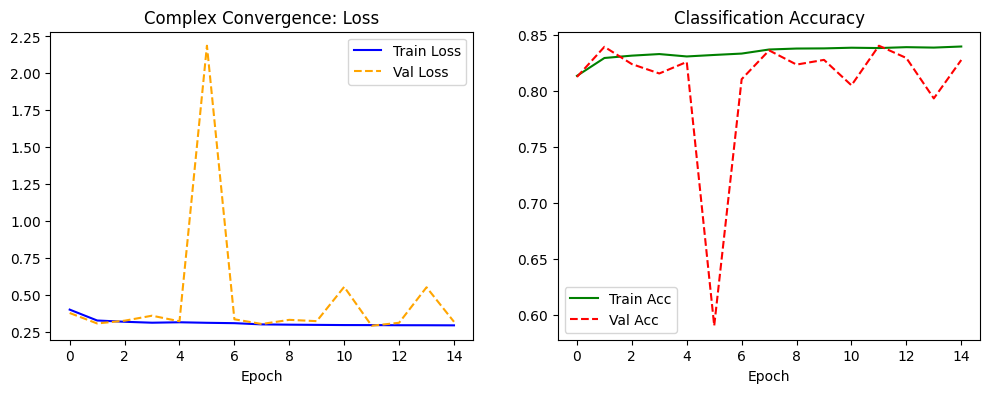

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='orange', linestyle='--')
plt.title('Complex Convergence: Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc', color='green')
plt.plot(history.history['val_accuracy'], label='Val Acc', color='red', linestyle='--')
plt.title('Classification Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.show()

Awaiting model weights upload (.keras or .h5):


Saving cv_ann_modulation_chunk_9.keras to cv_ann_modulation_chunk_9.keras
Restoring model state from: cv_ann_modulation_chunk_9.keras
Initializing validation data pipeline...
Executing model inference...

EVALUATION METRICS
Aggregate Accuracy (All SNRs):  84.02%
High-SNR Accuracy (>= +4 dB):   100.00%
Low-SNR Accuracy  (<=  0 dB):   62.14%


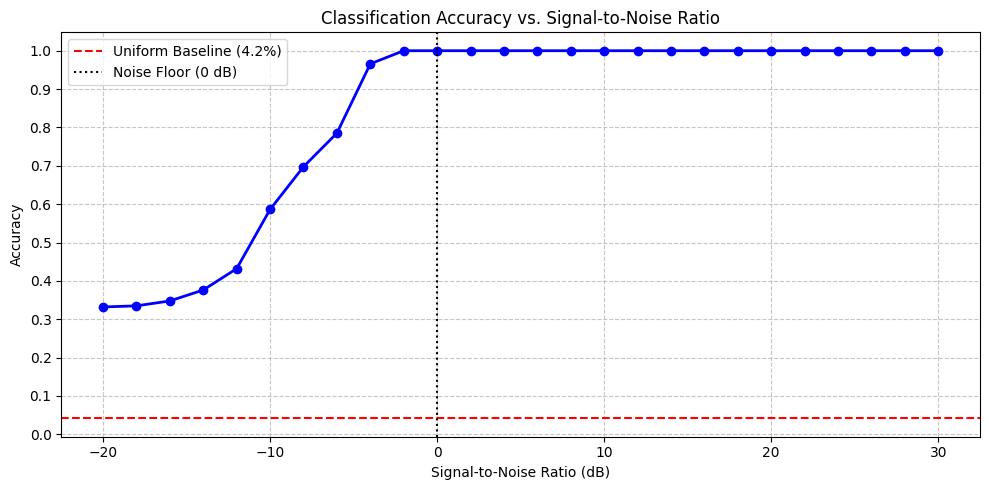


PHASE INVARIANCE ANALYSIS (ALL ACTIVE BANDS)
Target: FM         | Max Divergence: 0.000000000 | Status: PASSED
Target: GMSK       | Max Divergence: 0.000002623 | Status: PASSED
Target: OQPSK      | Max Divergence: 0.000000008 | Status: PASSED


In [9]:
import h5py
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from google.colab import files

print("Awaiting model weights upload (.keras or .h5):")
uploaded = files.upload()
weights_file = list(uploaded.keys())[0]

print(f"Restoring model state from: {weights_file}")
model.load_weights(weights_file)

print("Initializing validation data pipeline...")
data_path = h5_path if 'h5_path' in locals() else './chunk_data/chunk_1.h5'
with h5py.File(data_path, 'r') as f:
    if 'X_test' in f.keys():
        x_val, y_val, z_val = f['X_test'][:], f['Y_test'][:], f['Z_test'][:]
    else:
        x_train, y_train, z_train = f['X_train'][:], f['Y_train'][:], f['Z_train'][:]
        _, x_val, _, y_val, _, z_val = train_test_split(x_train, y_train, z_train, test_size=0.1, random_state=42)

print("Executing model inference...")
preds = model.predict(x_val, batch_size=1024, verbose=0)
y_pred = np.argmax(preds, axis=1)
y_true = np.argmax(y_val, axis=1)
z_flat = z_val.flatten()

high_snr_mask = z_flat >= 4
low_snr_mask = z_flat <= 0

acc_overall = np.mean(y_pred == y_true)
acc_high = np.mean(y_pred[high_snr_mask] == y_true[high_snr_mask]) if np.any(high_snr_mask) else 0
acc_low = np.mean(y_pred[low_snr_mask] == y_true[low_snr_mask]) if np.any(low_snr_mask) else 0

print("\n" + "="*65)
print("EVALUATION METRICS")
print("="*65)
print(f"Aggregate Accuracy (All SNRs):  {acc_overall * 100:.2f}%")
print(f"High-SNR Accuracy (>= +4 dB):   {acc_high * 100:.2f}%")
print(f"Low-SNR Accuracy  (<=  0 dB):   {acc_low * 100:.2f}%")
print("="*65)

# Generate Waterfall Curve
snrs = np.sort(np.unique(z_flat))
acc_scores = [np.mean(y_pred[z_flat == snr] == y_true[z_flat == snr]) for snr in snrs]

# Dynamically calculate baseline based on the number of classes in the current chunk
active_classes_count = y_val.shape[1]
uniform_baseline = 1.0 / active_classes_count

plt.figure(figsize=(10, 5))
plt.plot(snrs, acc_scores, marker='o', linestyle='-', color='b', linewidth=2)
plt.axhline(y=uniform_baseline, color='r', linestyle='--', label=f'Uniform Baseline ({uniform_baseline*100:.1f}%)')
plt.axvline(x=0, color='k', linestyle=':', label='Noise Floor (0 dB)')
plt.title('Classification Accuracy vs. Signal-to-Noise Ratio')
plt.xlabel('Signal-to-Noise Ratio (dB)')
plt.ylabel('Accuracy')
plt.yticks(np.arange(0, 1.1, 0.1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# COMPREHENSIVE PHASE INVARIANCE TEST FOR ALL ACTIVE BANDS
# ---------------------------------------------------------
print("\n" + "="*65)
print("PHASE INVARIANCE ANALYSIS (ALL ACTIVE BANDS)")
print("="*65)

classes = ['OOK','4ASK','8ASK','BPSK','QPSK','8PSK','16PSK','32PSK',
           '16APSK','32APSK','64APSK','128APSK','16QAM','32QAM',
           '64QAM','128QAM','256QAM','AM-SSB-WC','AM-SSB-SC',
           'AM-DSB-WC','AM-DSB-SC','FM','GMSK','OQPSK']


active_idx = np.unique(np.argmax(y_val, axis=1))

for cls_idx in active_idx:
    # Isolate the first sample belonging to this specific class
    sample_idx = np.where(np.argmax(y_val, axis=1) == cls_idx)[0][0]
    x_sample = x_val[sample_idx:sample_idx+1]

    # Base prediction
    pred_orig = model.predict(x_sample, verbose=0)

    # Introduce arbitrary 45-degree phase rotation
    theta = np.pi / 4
    I, Q = x_sample[0,:,0], x_sample[0,:,1]
    Z_complex = (I + 1j*Q) * np.exp(1j * theta)
    x_rot = np.stack([np.real(Z_complex), np.imag(Z_complex)], axis=1)[np.newaxis, ...]

    # Rotated prediction
    pred_rot = model.predict(x_rot, verbose=0)

    # Compute divergence across the probability distribution
    diff = np.max(np.abs(pred_orig - pred_rot))

    # Evaluate against standard GPU float32 precision limits
    mod_name = classes[cls_idx]
    status = "PASSED" if diff < 1e-3 else "FAILED"

    print(f"Target: {mod_name:10} | Max Divergence: {diff:.9f} | Status: {status}")

print("="*65)